# Первичный анализ муниципальных данных СберИндекса
Ноутбук работает с реальными XLSX и GPKG из репозитория. Цель — проверить, как соединять историю муниципалитетов с будущими рядами расходов, не создавая искусственные экономические шоки.
**Муниципального ряда расходов в проекте пока нет.** Добавленные национальные потребительские показатели проверены отдельно в `02_consumer_exports_audit.ipynb`. MAE, R² и качество обнаружения экономических шоков здесь не измеряются. Административные изменения не являются разметкой экономических шоков.
Интервалы действия: `year_from <= year < year_to`; `9999` — открытый конец, а не подтверждение актуальности справочника до этого года. [Описание автора СберИндекса](https://habr.com/ru/companies/sberbank/articles/849682/).

In [1]:
from pathlib import Path
import sys, json, platform
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 't_dict_municipal').exists():
    ROOT = ROOT.parent
assert (ROOT / 't_dict_municipal').exists(), 'Запускайте из корня проекта или notebooks/'
sys.path.insert(0, str(ROOT))
from src.municipal import (load_dictionary, load_geometry_metadata, sha256,
    active_in_year, interval_issues, attribute_transitions, transformation_events)
from src.evaluation import development_origins
REPORT = ROOT / 'artifacts' / 'eda'
REPORT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 10})
def show_figure(fig, name):
    path = REPORT / (name + '.png')
    fig.savefig(path, dpi=130, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(path)))
print('Python:', platform.python_version(), '| pandas:', pd.__version__)
print('Корень:', ROOT)

Python: 3.14.4 | pandas: 3.0.3
Корень: /home/bugor/Рабочий стол/sber_index


In [2]:
dictionary_path = ROOT / 't_dict_municipal/t_dict_municipal_districts.xlsx'
geometry_path = ROOT / 't_dict_municipal/t_dict_municipal_districts_poly.gpkg'
municipal = load_dictionary(dictionary_path)
geometry, contents, spatial, integrity = load_geometry_metadata(geometry_path)
metadata_path = ROOT / 'metadata_municipal_dict_sberindex_2.pdf'
metadata_config_path = ROOT / 'configs/municipal_metadata.json'
metadata = json.loads(metadata_config_path.read_text(encoding='utf-8'))
manifest = pd.DataFrame([{'file': str(p.relative_to(ROOT)), 'bytes': p.stat().st_size, 'sha256': sha256(p)} for p in [dictionary_path, geometry_path, metadata_path, metadata_config_path]])
display(manifest)
display(municipal.head())
display(contents.drop(columns=['description'], errors='ignore'))
display(spatial)
print('SQLite integrity_check:', integrity)

SQLite integrity_check: ok


,file,bytes,sha256
0,t_dict_municipal/t_dict_municipal_districts.xlsx,322024,4150658c3298fbc87ed79838f503f3a5b9a28da33257ff...
1,t_dict_municipal/t_dict_municipal_districts_po...,74334208,e62027630d48e4a13f9b6d173dd074d7358706743fe859...
2,metadata_municipal_dict_sberindex_2.pdf,333567,05707427a64061552d1f23f74f578a99fdabeff69f0c8a...
3,configs/municipal_metadata.json,1881,024478afbefd2bcd8539441e96a752c17c3bfb86b09a88...


,municipal_district_name_short,oktmo,municipal_district_name,municipal_district_type,municipal_district_status,shape,shape_linked_oktmo,municipal_district_center,source_rosstat,year_from,year_to,territory_id,change_id_from,change_id_to,region_code,region_name,municipal_district_center_lat,municipal_district_center_lon
0,Майкоп,79-701-000-000,городской округ город Майкоп,городской округ,административный_центр_субъекта,1,<NA>,г Майкоп,data-20180110-structure-20150128.csv,2018,9999,1,NaN,NaN,1,Республика Адыгея,44.606208,40.104053
1,Адыгейск,79-703-000-000,городской округ город Адыгейск,городской округ,NaN,1,<NA>,г Адыгейск,data-20180110-structure-20150128.csv,2018,9999,2,NaN,NaN,1,Республика Адыгея,44.883378,39.190962
2,Гиагинский,79-605-000-000,Гиагинский муниципальный район,муниципальный район,NaN,1,<NA>,ст-ца Гиагинская,data-20180110-structure-20150128.csv,2018,9999,3,NaN,NaN,1,Республика Адыгея,44.875585,40.056498
3,Кошехабльский,79-615-000-000,Кошехабльский муниципальный район,муниципальный район,NaN,1,<NA>,аул Кошехабль,data-20180110-structure-20150128.csv,2018,9999,4,NaN,NaN,1,Республика Адыгея,44.896500,40.496363
4,Красногвардейский,79-618-000-000,Красногвардейский муниципальный район,муниципальный район,NaN,1,<NA>,с Красногвардейское,data-20180110-structure-20150128.csv,2018,9999,5,NaN,NaN,1,Республика Адыгея,45.144356,39.586148


,table_name,data_type,identifier,last_change,min_x,min_y,max_x,max_y,srs_id
0,t_dict_municipal_districts_poly,features,t_dict_municipal_districts_poly,2024-10-17T12:11:38.270Z,-180.0,41.185097,180.0,82.058623,4326


,table_name,column_name,geometry_type_name,srs_id,z,m
0,t_dict_municipal_districts_poly,geom,GEOMETRY,4326,0,0


In [3]:
summary = {
    'dictionary_rows': len(municipal),
    'dictionary_columns': len(municipal.columns),
    'unique_territories': int(municipal.territory_id.nunique()),
    'unique_oktmo': int(municipal.oktmo.nunique()),
    'regions': int(municipal.region_code.nunique()),
    'geometry_rows': len(geometry),
    'territories_with_multiple_versions': int((municipal.groupby('territory_id').size() > 1).sum()),
    'minimum_year_from': int(municipal.year_from.min()),
    'maximum_year_from': int(municipal.year_from.max())
}
display(pd.Series(summary, name='value').to_frame())
missing = pd.DataFrame({'dtype': municipal.dtypes.astype(str), 'missing': municipal.isna().sum(), 'missing_pct': (municipal.isna().mean() * 100).round(2), 'nunique': municipal.nunique()})
display(missing)
display(Markdown('### Уточнения из приложенного PDF'))
display(Markdown('Покрытие: срезы на 1 января 2018–2024 включительно. Изменения в течение года отражаются к началу следующего. Центры оставлены по состоянию на 2018 год; их смена не прослеживается. Передачи частей территорий МО Чечни не учтены. Указанное в PDF ожидаемое обновление в июле 2025 года не подтверждает наличие такой версии в проекте.'))
federal_city = municipal.region_name.isin(metadata['administrative_centers']['coordinates_not_provided_for'])
center_missing = municipal[['municipal_district_center_lat','municipal_district_center_lon']].isna().any(axis=1)
center_partial = municipal.municipal_district_center_lat.isna() != municipal.municipal_district_center_lon.isna()
center_missing_by_region = municipal.loc[center_missing].groupby(['region_code','region_name']).size().rename('missing_coordinate_rows').reset_index()
display(center_missing_by_region)
print('Пропуски координат вне городов федерального значения:', int((center_missing & ~federal_city).sum()))
print('Частично заполненные пары координат:', int(center_partial.sum()))
display(Markdown('Все пропуски координат в текущих файлах объясняются указанными в PDF городами федерального значения. Возможный центроид полигона — отдельный геометрический признак, не административный центр; вычислять его следует в подходящей проекции и сохранять способ получения.'))
display(Markdown('Пропуски `change_id_*`, статуса и административного центра могут быть предусмотрены смыслом поля. `shape` — тип расположения центра: 1 внутри МО, 2 в соседнем МО, 3 центр также обслуживает соседнее МО. Это не индикатор отсутствующей геометрии.'))

Пропуски координат вне городов федерального значения: 0
Частично заполненные пары координат: 0


,value
dictionary_rows,3101
dictionary_columns,18
unique_territories,2660
unique_oktmo,3063
regions,85
geometry_rows,2660
territories_with_multiple_versions,438
minimum_year_from,2018
maximum_year_from,2024


,dtype,missing,missing_pct,nunique
municipal_district_name_short,str,0,0.00,2418
oktmo,string,0,0.00,3063
municipal_district_name,str,0,0.00,2924
municipal_district_type,str,0,0.00,4
municipal_district_status,str,2973,95.87,3
shape,Int64,0,0.00,3
shape_linked_oktmo,string,2742,88.42,324
municipal_district_center,str,262,8.45,2157
source_rosstat,str,0,0.00,27
year_from,Int64,0,0.00,7


### Уточнения из приложенного PDF

Покрытие: срезы на 1 января 2018–2024 включительно. Изменения в течение года отражаются к началу следующего. Центры оставлены по состоянию на 2018 год; их смена не прослеживается. Передачи частей территорий МО Чечни не учтены. Указанное в PDF ожидаемое обновление в июле 2025 года не подтверждает наличие такой версии в проекте.

,region_code,region_name,missing_coordinate_rows
0,77,Москва,146
1,78,Санкт-Петербург,112
2,92,Севастополь,10


Все пропуски координат в текущих файлах объясняются указанными в PDF городами федерального значения. Возможный центроид полигона — отдельный геометрический признак, не административный центр; вычислять его следует в подходящей проекции и сохранять способ получения.

Пропуски `change_id_*`, статуса и административного центра могут быть предусмотрены смыслом поля. `shape` — тип расположения центра: 1 внутри МО, 2 в соседнем МО, 3 центр также обслуживает соседнее МО. Это не индикатор отсутствующей геометрии.

In [4]:
territory_issues = interval_issues(municipal, 'territory_id')
oktmo_issues = interval_issues(municipal, 'oktmo')
geometry_issues = interval_issues(geometry, 'territory_id')
quality = pd.DataFrame([
    ('Полностью повторные строки справочника', int(municipal.duplicated().sum())),
    ('Пустые обязательные поля', int(municipal[['territory_id', 'oktmo', 'year_from', 'year_to', 'region_code']].isna().any(axis=1).sum())),
    ('Невалидные интервалы справочника', int((municipal.year_from >= municipal.year_to).sum())),
    ('Пересечения territory_id', int((territory_issues.issue == 'overlap').sum())),
    ('Разрывы territory_id', int((territory_issues.issue == 'gap').sum())),
    ('Пересечения ОКТМО', int((oktmo_issues.issue == 'overlap').sum())),
    ('Невалидные интервалы геослоя', int((geometry.year_from >= geometry.year_to).sum())),
    ('Пересечения версий геослоя', int((geometry_issues.issue == 'overlap').sum())),
    ('Повторные territory_id геослоя', int(geometry.territory_id.duplicated().sum())),
    ('Неверный формат ОКТМО', int((~municipal.oktmo.str.fullmatch(r'[0-9]{2}-[0-9]{3}-[0-9]{3}-[0-9]{3}', na=False)).sum()))
], columns=['check', 'count'])
display(quality)
display(oktmo_issues.head(15))
display(Markdown('Один ОКТМО за всю историю не обязательно обозначает одну территорию. При смене границ код может сохраняться. Нужны ключ и период действия; при соединении таблиц проверяем cardinality, а не просто число совпавших кодов.'))

,check,count
0,Полностью повторные строки справочника,0
1,Пустые обязательные поля,0
2,Невалидные интервалы справочника,0
3,Пересечения territory_id,0
4,Разрывы territory_id,0
5,Пересечения ОКТМО,0
6,Невалидные интервалы геослоя,0
7,Пересечения версий геослоя,0
8,Повторные territory_id геослоя,0
9,Неверный формат ОКТМО,0


,key,issue,left_from,left_to,right_from


Один ОКТМО за всю историю не обязательно обозначает одну территорию. При смене границ код может сохраняться. Нужны ключ и период действия; при соединении таблиц проверяем cardinality, а не просто число совпавших кодов.

In [5]:
dictionary_ids = set(municipal.territory_id)
geometry_ids = set(geometry.territory_id)
print('Территории без геометрии:', len(dictionary_ids - geometry_ids))
print('Геометрии без записи справочника:', len(geometry_ids - dictionary_ids))
joined = municipal.merge(geometry[['territory_id', 'year_from', 'year_to']].rename(columns={'year_from': 'geom_from', 'year_to': 'geom_to'}), on='territory_id', how='left', validate='many_to_one', indicator=True)
interval_mismatch = joined[(joined.year_from < joined.geom_from) | (joined.year_to > joined.geom_to) | (joined._merge != 'both')]
print('Версии атрибутов вне интервала геометрии:', len(interval_mismatch))
envelope_ok = (geometry.xmin <= geometry.xmax) & (geometry.ymin <= geometry.ymax) & geometry.xmin.between(-180, 180) & geometry.xmax.between(-180, 180) & geometry.ymin.between(-90, 90) & geometry.ymax.between(-90, 90)
display(pd.Series({
    'invalid_gpkg_headers': int((~geometry.valid_header).sum()),
    'empty_geometry_flag': int(geometry['empty'].fillna(True).sum()),
    'missing_envelopes': int(geometry[['xmin','xmax','ymin','ymax']].isna().any(axis=1).sum()),
    'invalid_envelope_bounds': int((~envelope_ok).sum()),
    'srs_id_not_4326': int((geometry.srs_id != 4326).sum()),
    'version_interval_mismatches': len(interval_mismatch)
}, name='count').to_frame())
display(Markdown('Проверены заголовки GeoPackage, система координат, прямоугольники охвата и связи таблиц. Топологическая корректность полигонов, площади наложений и полнота покрытия территории здесь не проверены. Для этого нужен отдельный геоаудит Shapely/GeoPandas в подходящей проекции.'))

Территории без геометрии: 0
Геометрии без записи справочника: 0
Версии атрибутов вне интервала геометрии: 0


,count
invalid_gpkg_headers,0
empty_geometry_flag,0
missing_envelopes,0
invalid_envelope_bounds,0
srs_id_not_4326,0
version_interval_mismatches,0


Проверены заголовки GeoPackage, система координат, прямоугольники охвата и связи таблиц. Топологическая корректность полигонов, площади наложений и полнота покрытия территории здесь не проверены. Для этого нужен отдельный геоаудит Shapely/GeoPandas в подходящей проекции.

,year,active_versions,unique_territories,active_geometries,regions,duplicate_active_oktmo
0,2018,2617,2617,2617,85,0
1,2019,2612,2612,2612,85,0
2,2020,2608,2608,2608,85,0
3,2021,2603,2603,2603,85,0
4,2022,2603,2603,2603,85,0
5,2023,2596,2596,2596,85,0
6,2024,2594,2594,2594,85,0


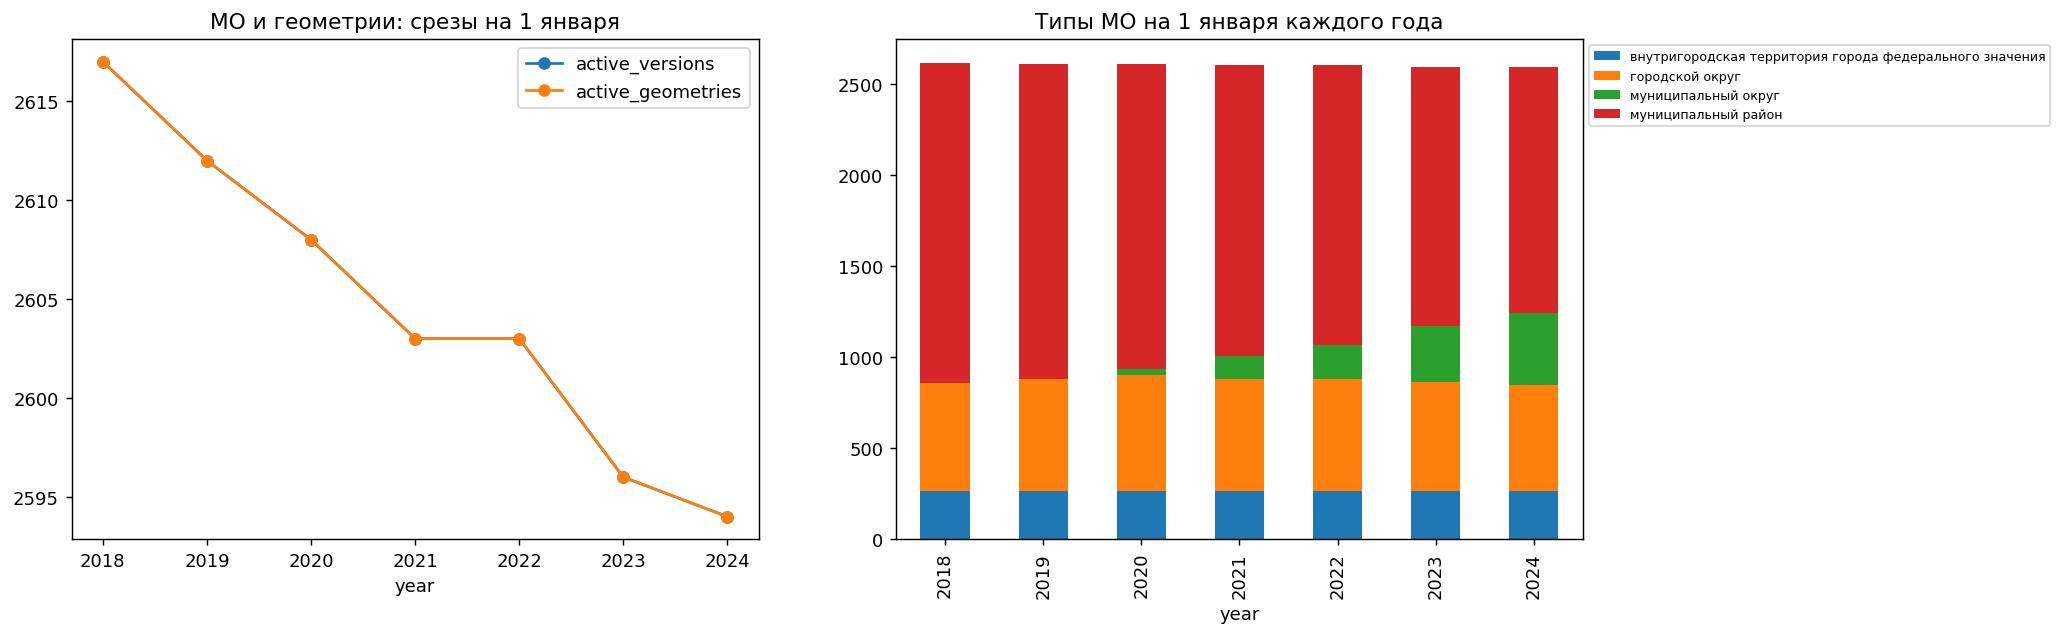

Показываем срезы на 1 января 2018–2024, согласно PDF. Строка с year_from=2024 не устанавливает месяц преобразования и не означает наблюдение изменений в течение всего 2024 года. Открытые интервалы не подтверждают актуальность после 01.01.2024.

In [6]:
VERIFIED_LAST_YEAR = int(metadata['coverage_end_snapshot'][:4])
assert int(municipal.year_from.max()) <= VERIFIED_LAST_YEAR
annual_records = []
annual_types = []
for year in range(int(municipal.year_from.min()), VERIFIED_LAST_YEAR + 1):
    current = active_in_year(municipal, year)
    current_geom = active_in_year(geometry, year)
    annual_records.append({'year': year, 'active_versions': len(current), 'unique_territories': current.territory_id.nunique(), 'active_geometries': len(current_geom), 'regions': current.region_code.nunique(), 'duplicate_active_oktmo': int(current.oktmo.duplicated().sum())})
    annual_types.extend({'year': year, 'type': kind, 'count': count} for kind, count in current.municipal_district_type.value_counts().items())
annual = pd.DataFrame(annual_records)
type_panel = pd.DataFrame(annual_types).pivot(index='year', columns='type', values='count').fillna(0)
display(annual)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
annual.plot(x='year', y=['active_versions', 'active_geometries'], marker='o', ax=axes[0], title='МО и геометрии: срезы на 1 января')
type_panel.plot(kind='bar', stacked=True, ax=axes[1], title='Типы МО на 1 января каждого года')
axes[1].legend(fontsize=7, loc='upper left', bbox_to_anchor=(1,1))
show_figure(fig, 'annual_structure')
display(Markdown('Показываем срезы на 1 января 2018–2024, согласно PDF. Строка с year_from=2024 не устанавливает месяц преобразования и не означает наблюдение изменений в течение всего 2024 года. Открытые интервалы не подтверждают актуальность после 01.01.2024.'))

,count
name_changed,440
type_changed,436
oktmo_changed,437
status_changed,2


transitions
type_before                                        type_after                                                     
муниципальный район                                муниципальный округ                                         346
                                                   городской округ                                              48
городской округ                                    муниципальный округ                                          42
                                                   городской округ                                               3
внутригородская территория города федерального ... внутригородская территория города федерального ...            1
муниципальный район                                муниципальный район                                           1

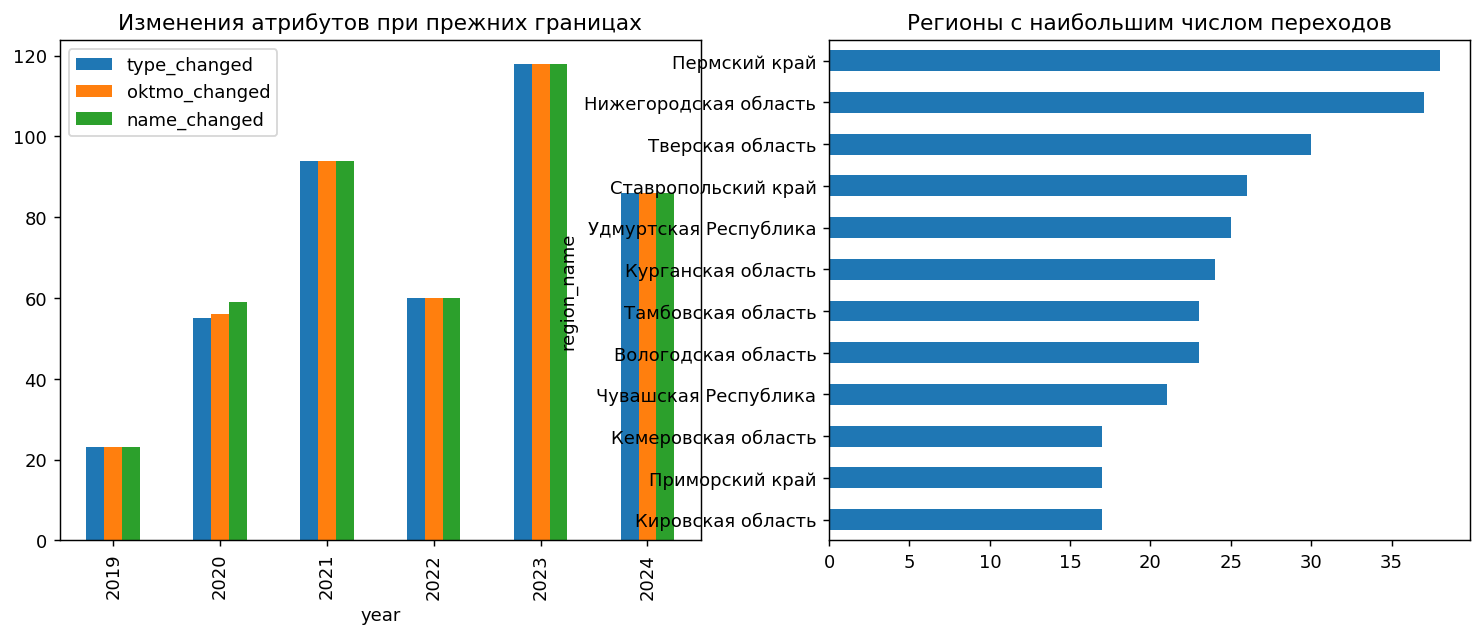

Изменения имени, типа и ОКТМО могут происходить одновременно; суммы этих категорий нельзя считать числом независимых событий. Полное название также включает тип МО, поэтому изменение полного имени может отражать смену типа.

In [7]:
transitions = attribute_transitions(municipal)
display(transitions[['name_changed', 'type_changed', 'oktmo_changed', 'status_changed']].sum().rename('count').to_frame())
display(transitions.groupby(['type_before', 'type_after']).size().sort_values(ascending=False).rename('transitions').to_frame().head(12))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
transitions.groupby('year')[['type_changed','oktmo_changed','name_changed']].sum().plot(kind='bar', ax=axes[0], title='Изменения атрибутов при прежних границах')
transitions.groupby('region_name').size().nlargest(12).sort_values().plot(kind='barh', ax=axes[1], title='Регионы с наибольшим числом переходов')
show_figure(fig, 'attribute_changes')
display(Markdown('Изменения имени, типа и ОКТМО могут происходить одновременно; суммы этих категорий нельзя считать числом независимых событий. Полное название также включает тип МО, поэтому изменение полного имени может отражать смену типа.'))

In [8]:
columns = ['territory_id', 'municipal_district_name', 'municipal_district_type', 'oktmo', 'year_from', 'year_to', 'change_id_from', 'change_id_to']
display(Markdown('### Пример 1. Беломорский: смена типа и кода при неизменной территории'))
display(municipal.loc[municipal.municipal_district_name_short.str.contains('Беломор', na=False), columns].sort_values(['territory_id','year_from']))
display(Markdown('### Пример 2. Серпухов: проверить код и территорию отдельно'))
display(municipal.loc[municipal.municipal_district_name.str.contains('Серпухов', case=False, na=False), columns].sort_values(['year_from','territory_id']))
display(Markdown('Историю первой группы допустимо соединять по постоянной территории после проверки методологии показателя. Для второй нужен анализ преобразования: сохранение ОКТМО само по себе недостаточно для непрерывного ряда.'))

### Пример 1. Беломорский: смена типа и кода при неизменной территории

,territory_id,municipal_district_name,municipal_district_type,oktmo,year_from,year_to,change_id_from,change_id_to
207,208,Беломорский муниципальный район,муниципальный район,86-604-000-000,2018,2024,NaN,NaN
3029,208,Беломорский муниципальный округ,муниципальный округ,86-504-000-000,2024,9999,NaN,NaN


### Пример 2. Серпухов: проверить код и территорию отдельно

,territory_id,municipal_district_name,municipal_district_type,oktmo,year_from,year_to,change_id_from,change_id_to
1478,1479,городской округ Серпухов,городской округ,46-770-000-000,2018,2019,NaN,union_5
1501,1502,Серпуховский муниципальный район,муниципальный район,46-651-000-000,2018,2019,NaN,union_5
2643,2644,городской округ Серпухов,городской округ,46-770-000-000,2019,9999,union_5,NaN


Историю первой группы допустимо соединять по постоянной территории после проверки методологии показателя. Для второй нужен анализ преобразования: сохранение ОКТМО само по себе недостаточно для непрерывного ряда.

In [9]:
events = transformation_events(municipal)
event_kinds = events.groupby('kind').agg(events=('change_id','size'), rows_before=('n_before','sum'), rows_after=('n_after','sum')).reset_index()
event_kinds['description'] = event_kinds.kind.map(metadata['transformation_types'])
display(event_kinds)
print('Неописанные в PDF типы:', sorted(set(events.kind) - set(metadata['transformation_types'])))
display(Markdown('Полнота связей проверяется только для зарегистрированных событий. Согласно PDF, передачи частей территорий в Чечне в справочник не включены. Для этого региона сохраняем флаг ограничения и отдельно сравниваем результаты с его включением и исключением.'))
display(events.head(12))
event_issues = events[(~events.both_sides_present) | (~events.years_match)]
print('Трансформации с неполными сторонами или несовпадающими годами:', len(event_issues))
display(event_issues)
display(Markdown('Это граф административных преобразований, полученный по `change_id_from/to`. Для объединений аддитивные суммы можно согласовать только при полном составе и отсутствии двойного счёта. Удельные показатели требуют числителя и знаменателя; разделение территории по площади не восстанавливает расходы жителей.'))

Неописанные в PDF типы: []
Трансформации с неполными сторонами или несовпадающими годами: 0


,kind,events,rows_before,rows_after,description
0,disunion,1,1,2,разделение/выделение
1,transfer,9,18,18,передача части территории
2,union,23,47,23,объединение/присоединение


Полнота связей проверяется только для зарегистрированных событий. Согласно PDF, передачи частей территорий в Чечне в справочник не включены. Для этого региона сохраняем флаг ограничения и отдельно сравниваем результаты с его включением и исключением.

,change_id,kind,n_before,n_after,territories_before,territories_after,years_before,years_after,both_sides_present,years_match
0,disunion_1,disunion,1,2,628,2748|2812,[2021],[2021],True,True
1,transfer_1,transfer,2,2,1199|1202,2646|2647,[2019],[2019],True,True
2,transfer_2,transfer,2,2,1462|1505,2648|2649,[2019],[2019],True,True
3,transfer_3,transfer,2,2,816|837,2876|2881,[2022],[2022],True,True
4,transfer_4,transfer,2,2,1911|1946,2877|2878,[2022],[2022],True,True
5,transfer_5,transfer,2,2,2240|2246,2872|2880,[2022],[2022],True,True
6,transfer_6,transfer,2,2,2239|2247,2879|2882,[2022],[2022],True,True
7,transfer_7,transfer,2,2,1482|1503,3008|3013,[2023],[2023],True,True
8,transfer_8,transfer,2,2,2071|2097,3009|3010,[2023],[2023],True,True
9,transfer_9,transfer,2,2,2277|2306,3011|3012,[2023],[2023],True,True


,change_id,kind,n_before,n_after,territories_before,territories_after,years_before,years_after,both_sides_present,years_match


Это граф административных преобразований, полученный по `change_id_from/to`. Для объединений аддитивные суммы можно согласовать только при полном составе и отсутствии двойного счёта. Удельные показатели требуют числителя и знаменателя; разделение территории по площади не восстанавливает расходы жителей.

Активные МО с координатами центра: 2327 / 2594
Непустые, но невалидные координаты: 0


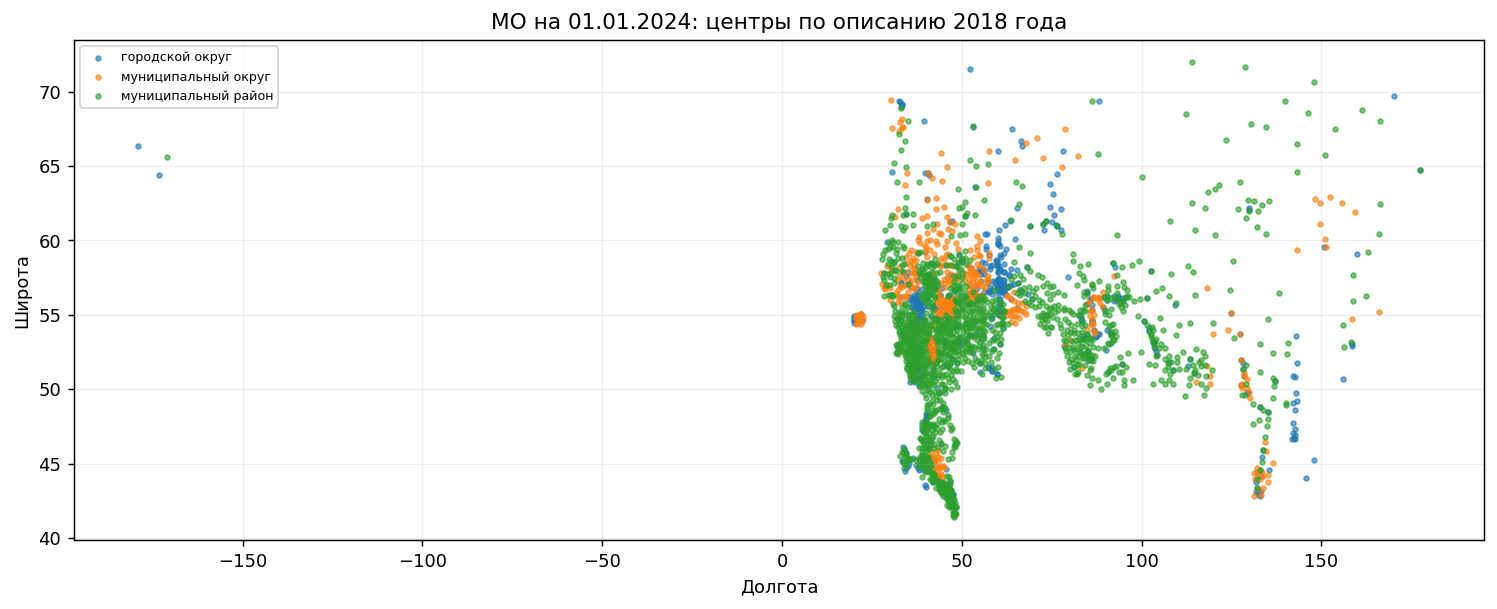

Координаты и названия центров не являются достоверной историей перемещения центров: в PDF указан фиксированный вариант 2018 года. Не использовать этот слой как датированное свидетельство изменений локации центра.

In [10]:
current = active_in_year(municipal, VERIFIED_LAST_YEAR)
valid_centers = current.municipal_district_center_lat.between(-90,90) & current.municipal_district_center_lon.between(-180,180)
print('Активные МО с координатами центра:', int(valid_centers.sum()), '/', len(current))
print('Непустые, но невалидные координаты:', int((current[['municipal_district_center_lat','municipal_district_center_lon']].notna().all(axis=1) & ~valid_centers).sum()))
fig, ax = plt.subplots(figsize=(14,5))
for kind, group in current[valid_centers].groupby('municipal_district_type'):
    ax.scatter(group.municipal_district_center_lon, group.municipal_district_center_lat, s=7, alpha=.6, label=kind)
ax.set(xlabel='Долгота', ylabel='Широта', title=f'МО на 01.01.{VERIFIED_LAST_YEAR}: центры по описанию 2018 года')
ax.legend(fontsize=7)
ax.grid(alpha=.2)
show_figure(fig, 'municipal_centers')
display(Markdown('Координаты и названия центров не являются достоверной историей перемещения центров: в PDF указан фиксированный вариант 2018 года. Не использовать этот слой как датированное свидетельство изменений локации центра.'))

In [11]:
# Демонстрация временного lookup на реальных строках справочника, не на расходах.
demo = municipal.loc[municipal.municipal_district_name_short.str.contains('Беломор', na=False), ['territory_id','oktmo','year_from']].rename(columns={'year_from':'observation_year'})
candidates = demo.merge(municipal[['territory_id','oktmo','year_from','year_to','municipal_district_type']], on='oktmo', suffixes=('_expected','_matched'), how='left')
matched = candidates[(candidates.year_from <= candidates.observation_year) & (candidates.observation_year < candidates.year_to)]
display(matched)
assert len(matched) == len(demo)
assert (matched.territory_id_expected == matched.territory_id_matched).all()
display(Markdown('При добавлении расходов сначала выясняем, что означает их `id`: `territory_id`, ОКТМО или отдельный ключ набора. Используем официальный crosswalk; совпадение чисел и названий не является доказательством соответствия. Отдельно фиксируем момент доступности каждой статистической записи.'))

,territory_id_expected,oktmo,observation_year,territory_id_matched,year_from,year_to,municipal_district_type
0,208,86-604-000-000,2018,208,2018,2024,муниципальный район
1,208,86-504-000-000,2024,208,2024,9999,муниципальный округ


При добавлении расходов сначала выясняем, что означает их `id`: `territory_id`, ОКТМО или отдельный ключ набора. Используем официальный crosswalk; совпадение чисел и названий не является доказательством соответствия. Отдельно фиксируем момент доступности каждой статистической записи.

## План честной временной валидации
Все МО делятся по общим календарным отсечениям. На каждом origin модель видит только доступные к моменту прогноза значения. Лаги, нормировки, агрегаты региона, новости и Росстат рассчитываются заново внутри фолда. Для обучения direct-модели метка `y[t+h]` должна уже быть опубликована к origin.
Горизонты 1/3/6/12 — значение конкретного месяца `origin+h`, а не среднее следующих h месяцев. Последние 12 месяцев оставляем финальным holdout. Dev-origin допускается, только если все его оцениваемые цели лежат раньше holdout. Не хватает истории — сообщаем ограничение и уменьшаем число методов или пересматриваем протокол до запуска.
В следующей ячейке только иллюстративный календарь 2018–2024. Он не утверждает наличие ряда расходов за эти годы. Подробный план: `docs/MODELING_PLAN_RU.md`.

In [12]:
example_calendar = pd.date_range('2018-01-01', '2024-12-01', freq='MS')
folds = development_origins(example_calendar, minimum_train_months=36, holdout_months=12, max_horizon=12)
display(folds.head())
display(folds.tail())
print('Dev origins на иллюстративном календаре:', len(folds))
assert (folds.max_target < folds.holdout_start).all()
display(Markdown('MAE считается в исходных единицах расходов по каждому горизонту. Основная метрика — среднее MAE муниципалитетов; рядом сохраняются общий MAE, покрытие и R². Все модели сравниваем на одинаковых ключах. Незаполненные прогнозы отражаем в coverage; удаление сложных МО не должно улучшать рейтинг.'))

Dev origins на иллюстративном календаре: 25


,origin,max_target,holdout_start
0,2020-12-01,2021-12-01,2024-01-01
1,2021-01-01,2022-01-01,2024-01-01
2,2021-02-01,2022-02-01,2024-01-01
3,2021-03-01,2022-03-01,2024-01-01
4,2021-04-01,2022-04-01,2024-01-01


,origin,max_target,holdout_start
20,2022-08-01,2023-08-01,2024-01-01
21,2022-09-01,2023-09-01,2024-01-01
22,2022-10-01,2023-10-01,2024-01-01
23,2022-11-01,2023-11-01,2024-01-01
24,2022-12-01,2023-12-01,2024-01-01


MAE считается в исходных единицах расходов по каждому горизонту. Основная метрика — среднее MAE муниципалитетов; рядом сохраняются общий MAE, покрытие и R². Все модели сравниваем на одинаковых ключах. Незаполненные прогнозы отражаем в coverage; удаление сложных МО не должно улучшать рейтинг.

In [13]:
summary.update({
    'attribute_transitions': len(transitions),
    'type_changes': int(transitions.type_changed.sum()),
    'oktmo_changes': int(transitions.oktmo_changed.sum()),
    'name_changes': int(transitions.name_changed.sum()),
    'status_changes': int(transitions.status_changed.sum()),
    'coverage_end_snapshot': metadata['coverage_end_snapshot'],
    'administrative_center_reference_year': metadata['administrative_centers']['reference_year'],
    'expected_missing_center_coordinate_rows': int((center_missing & federal_city).sum()),
    'unexpected_missing_center_coordinate_rows': int((center_missing & ~federal_city).sum()),
    'chechnya_dictionary_rows': int(municipal.region_name.str.contains('Чеч', na=False).sum()),
    'chechnya_boundary_transfers_not_tracked': True,
    'transformation_events': len(events),
    'event_link_issues': len(event_issues),
    'dictionary_geometry_interval_mismatches': len(interval_mismatch),
    'sqlite_integrity': integrity,
    'municipal_consumption_file_present': (ROOT / 'data/raw/consumption.csv').exists()
})
tables = {'input_manifest': manifest, 'missing_values': missing.reset_index(names='column'), 'quality_checks': quality, 'missing_centers_by_region': center_missing_by_region, 'annual_structure': annual, 'attribute_transitions': transitions, 'transformation_events': events, 'transformation_kinds': event_kinds, 'event_issues': event_issues, 'interval_issues_territory': territory_issues, 'interval_issues_oktmo': oktmo_issues, 'geometry_interval_mismatches': interval_mismatch.drop(columns='_merge')}
for name, table in tables.items():
    table.to_csv(REPORT / (name + '.csv'), index=False)
(REPORT / 'summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2) + chr(10), encoding='utf-8')
print('Сохранены:', ', '.join(sorted(p.name for p in REPORT.iterdir())))
display(pd.Series(summary, name='value').to_frame())
display(Markdown('Национальные временные ряды расходов уже добавлены; их аудит выполнен в 02_consumer_exports_audit.ipynb. Для муниципальной задачи следующий шаг — добавить расходы МО с описанием единиц, частоты, территориального ключа и дат доступности. Затем провести аудит панели, зафиксировать оценочную сетку и запустить одинаковый backtest для baseline и кандидатов. Численных результатов моделей пока нет.'))

Сохранены: annual_structure.csv, annual_structure.png, attribute_changes.png, attribute_transitions.csv, event_issues.csv, geometry_interval_mismatches.csv, input_manifest.csv, interval_issues_oktmo.csv, interval_issues_territory.csv, missing_centers_by_region.csv, missing_values.csv, municipal_centers.png, municipal_data_audit.html, quality_checks.csv, summary.json, transformation_events.csv, transformation_kinds.csv


,value
dictionary_rows,3101
dictionary_columns,18
unique_territories,2660
unique_oktmo,3063
regions,85
geometry_rows,2660
territories_with_multiple_versions,438
minimum_year_from,2018
maximum_year_from,2024
attribute_transitions,441


Национальные временные ряды расходов уже добавлены; их аудит выполнен в 02_consumer_exports_audit.ipynb. Для муниципальной задачи следующий шаг — добавить расходы МО с описанием единиц, частоты, территориального ключа и дат доступности. Затем провести аудит панели, зафиксировать оценочную сетку и запустить одинаковый backtest для baseline и кандидатов. Численных результатов моделей пока нет.